In [ ]:
# for latex rendering in plotly
import plotly
from IPython.display import HTML, display

plotly.offline.init_notebook_mode()
display(
    HTML(
        '<script type="text/javascript" async src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.1/MathJax.js?config=TeX-MML-AM_SVG"></script>'
    )
)

# Demo

This demo walks through:
1. Making a layer/gate set for an IBM device.
2. Creating a 2-local Pauli-Lindblad model based on the device topology.
3. Build "vanilla" Pauli-Lindblad learning experiments.
4. Running the experiments.
5. Fitting the model and getting noise maps.

In [ ]:
from qiskit_ibm_runtime import Executor, QiskitRuntimeService

runtime = QiskitRuntimeService(name="foo")
backend = runtime.backend("ibm_marrakesh")
executor = Executor(backend)

## 1. Build a gate set with a single layer on a ring of qubits

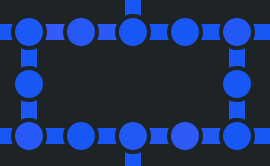

In [ ]:
from qiskit_noise_learning.gate_sets import QiskitGateSet

qubit_subset = [*range(25, 30), *range(37, 39), *range(45, 50)]
gate_set = QiskitGateSet(backend.num_qubits, target=backend.target, qubit_subset=qubit_subset)

layer_1_pairs = [(25, 26), (27, 28), (29, 38), (37, 45), (46, 47), (48, 49)]

with gate_set.build_new_gate("layer_1", latex_str=r"\mathrm{CZ}") as builder:
    for pair in layer_1_pairs:
        builder.circuit.cz(*pair)

In [ ]:
gate_set.draw()

## 2. Create a 2-local Pauli-Lindblad model.

In [ ]:
from qiskit_noise_learning.models import PauliLindbladModel

pauli_lindblad_model = PauliLindbladModel.k_local(gate_set, gate_k={"layer_1": 2, "M": 1, "P": 1})

## 3. Build learning experiments

In [ ]:
from qiskit_noise_learning.experiment_builder import (
    BindSequenceDepths,
    CompleteSequences,
    EvenDepthVanillaPaths,
    Experiment,
    GenerateInstructionSequences,
    IdentifyRelations,
    MergeInstructionSequences,
    SPAMPaths,
    VanillaInstructionSequences,
)

experiment = Experiment(fidelity_model=pauli_lindblad_model, shots=20, randomizations=50)

experiment_builder = (
    # add vanilla paths and instruction sequences, and relate them
    EvenDepthVanillaPaths()
    + VanillaInstructionSequences()
    + IdentifyRelations()
    # add spam paths, and auto-generate corresponding instruction sequences
    + SPAMPaths()
    + GenerateInstructionSequences()
    # merge and complete instruction sequences
    + MergeInstructionSequences()
    + CompleteSequences()
    # set numerical parameters
    + BindSequenceDepths([2, 16, 32, 64, 128])
)

experiment = experiment_builder.run(experiment)

print(f"Number of paths: {len(experiment.paths)}")
print(f"Number of instruction sequences: {len(experiment.instruction_sequences)}")

## 4. Run experiments

In [ ]:
from qiskit.transpiler import PassManager
from qiskit_addon_utils.noise_management.post_selection.transpiler.passes import (
    AddPostSelectionMeasures,
    AddSpectatorMeasures,
)

from qiskit_noise_learning.circuit_generator import ExecutorCircuitGenerator

# build post selection pass manager
post_selection_pm = PassManager(
    [
        AddSpectatorMeasures(backend.coupling_map),
        AddPostSelectionMeasures(x_pulse_type="rx"),
    ]
)

circuit_generator = ExecutorCircuitGenerator(gate_set, pass_manager=post_selection_pm)
quantum_program, data_mapper = circuit_generator.generate(experiment)

print(f"Number of template circuits: {len(quantum_program.items)}")
print("Depth 2 template circuit:")
quantum_program.items[0].circuit.draw("mpl", idle_wires=False, fold=False)

In [ ]:
# run program and provide initial population of fit
# job = executor.run(quantum_program)
job = runtime.job("d9ag4krv6alc73crnjg0")  # previous job
fit = circuit_generator.collect(job.result(), data_mapper)

## 5. Analyzing the data

In [ ]:
from qiskit_noise_learning.analysis import (
    ComputeObservables,
    CurveFitObservables,
    FlipPostSelect,
    NNLSSolve,
)

analyzer = FlipPostSelect() + ComputeObservables() + CurveFitObservables() + NNLSSolve()

fit = analyzer.run(fit)

Check percentage of shots removed by post-selection.

In [ ]:
fit.raw_data.datatree["0"]["data_mask"].mean()

Plot the exponential fit v.s. the observable means on a qubit-pair basis.

In [ ]:
fit.plot_qubit_pair_decays(
    pairs=layer_1_pairs,
    observable_type="means",
    exponential_fit=True,
)

Plot the predicted model decays v.s. the observable means on a qubit-pair basis.

In [ ]:
fit.plot_qubit_pair_decays(
    pairs=layer_1_pairs,
    observable_type="means",
    model_prediction=True,
)